# 02 — Exploratory Data Analysis

Establish what the FOX vs NBC headline classifier has to work with:
class balance, time coverage, headline style, and the topic / author surface.

Key questions answered here:
1. How balanced are the classes?
2. Over what time window were articles published, and is coverage even across sources?
3. Do headline length and punctuation differ between sources?
4. What words/phrases are most distinctive of each source?
5. Are topics evenly distributed?

Findings here motivate decisions in `03_modeling.ipynb` — in particular, the
*time-stratified* train/test split and the choice of word + character + style
feature union.

In [1]:
from pathlib import Path
import html, re, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

ROOT = Path.cwd().resolve().parent
RAW  = ROOT / 'data' / 'raw'

## 1. Load the combined dataset

Both source CSVs are concatenated into a single long-form DataFrame with a
`source ∈ {FOX, NBC}` label and a parsed datetime column. Empty / duplicate
headlines are dropped at the same time.

In [2]:
def normalize_raw(x):
    if pd.isna(x): return ''
    s = unicodedata.normalize('NFKC', html.unescape(str(x)))
    return re.sub(r'\s+', ' ', s).strip()

fox = pd.read_csv(RAW / 'fox_scraped_all.csv')
nbc = pd.read_csv(RAW / 'nbc_scraped_all.csv')
fox['source'] = 'FOX'
nbc['source'] = 'NBC'

df = pd.concat([fox, nbc], ignore_index=True)
df['title']    = df['title'].map(normalize_raw)
df['subtitle'] = df['subtitle'].map(normalize_raw)
df['datetime_posted'] = pd.to_datetime(df['datetime_posted'], utc=True, errors='coerce', format='mixed')
df = df[df['title'] != ''].drop_duplicates(['title', 'source']).reset_index(drop=True)
df.shape, df.columns.tolist()

((3799, 8),
 ['url',
  'topic',
  'title',
  'subtitle',
  'author',
  'datetime_posted',
  'label',
  'source'])

## 2. Class balance

Roughly even (~52 / 48), so accuracy is a reasonable headline metric and we
don't need aggressive class re-weighting.

In [3]:
balance = df['source'].value_counts().rename('count').to_frame()
balance['fraction'] = balance['count'] / balance['count'].sum()
balance

,count,fraction
source,,
FOX,2000,0.526454
NBC,1799,0.473546


## 3. Time coverage per source

Date range and per-month counts. Coverage that is uneven over time is exactly
the reason a *time-stratified* holdout is more honest than a random one — it
prevents leakage from articles with similar topics published on the same day
ending up in both train and test.

In [4]:
time_summary = df.groupby('source')['datetime_posted'].agg(['min', 'max', 'count']).rename(columns={'count':'rows_with_date'})
time_summary['rows_total']  = df.groupby('source').size()
time_summary['rows_no_date'] = time_summary['rows_total'] - time_summary['rows_with_date']
time_summary

,min,max,rows_with_date,rows_total,rows_no_date
source,,,,,
FOX,2020-01-17 14:38:33+00:00,2025-03-16 12:00:22+00:00,2000,2000,0
NBC,2020-01-06 17:10:00+00:00,2026-04-07 20:29:18.893000+00:00,1798,1799,1


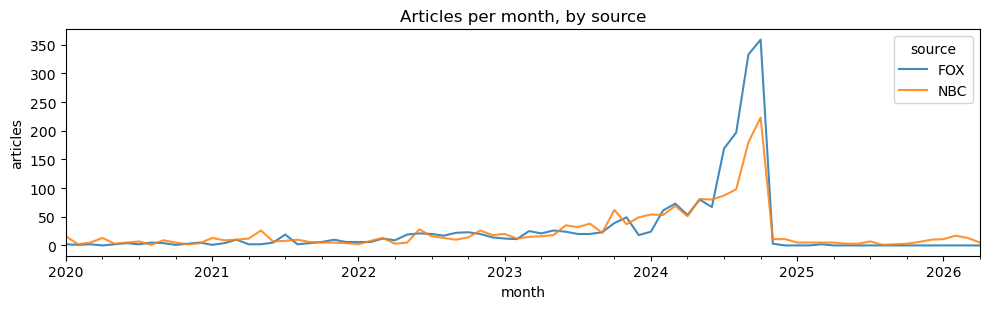

In [5]:
monthly = (df.dropna(subset=['datetime_posted'])
             .assign(month=lambda d: d['datetime_posted'].dt.tz_convert(None).dt.to_period('M').dt.to_timestamp())
             .groupby(['month', 'source']).size().unstack(fill_value=0))

ax = monthly.plot(figsize=(10, 3.2), alpha=0.85)
ax.set_title('Articles per month, by source')
ax.set_xlabel('month')
ax.set_ylabel('articles')
plt.tight_layout(); plt.show()

## 4. Headline length distribution

Headline length is a real signal: NBC headlines tend to run longer (more
descriptive lead-ins like *'As X happens, Y...'*), while FOX headlines run
shorter and punchier. This is captured downstream by the hand-crafted style
features.

In [6]:
df['n_chars'] = df['title'].str.len()
df['n_words'] = df['title'].str.split().map(len)

length_stats = df.groupby('source')[['n_chars', 'n_words']].agg(['mean', 'median', 'std']).round(2)
length_stats

n_chars               n_words             
          mean median    std    mean median   std
source                                           
FOX      88.69   90.0  15.14   13.76   14.0  2.58
NBC      73.68   73.0  17.23   11.84   12.0  2.89

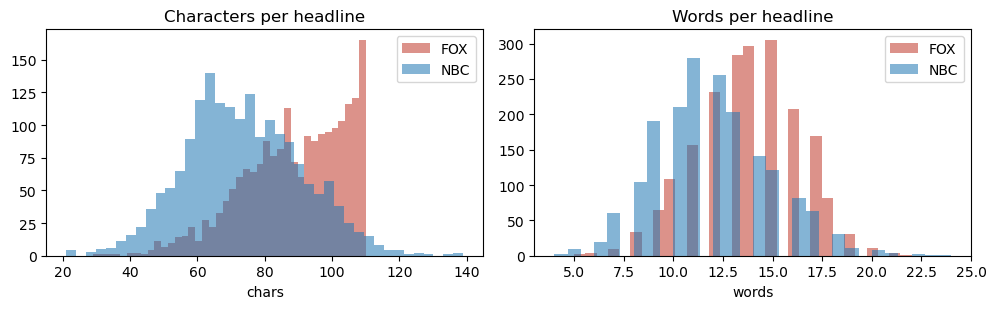

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
for src, color in [('FOX', '#c0392b'), ('NBC', '#1f77b4')]:
    s = df[df['source'] == src]
    axes[0].hist(s['n_chars'], bins=40, alpha=0.55, label=src, color=color)
    axes[1].hist(s['n_words'], bins=30, alpha=0.55, label=src, color=color)
axes[0].set_title('Characters per headline'); axes[0].set_xlabel('chars'); axes[0].legend()
axes[1].set_title('Words per headline');      axes[1].set_xlabel('words'); axes[1].legend()
plt.tight_layout(); plt.show()

## 5. Style and punctuation

Per-headline summary of stylistic markers. Differences here justify adding
hand-crafted style features to the model in addition to TF-IDF.

In [8]:
def style_row(s):
    s = s or ''
    words = s.split() or ['']
    return pd.Series({
        'has_question':   float('?' in s),
        'has_exclaim':    float('!' in s),
        'has_colon':      float(':' in s),
        'has_quote':      float(any(q in s for q in '"“”‘’')),
        'has_emdash':     float('—' in s),
        'cap_word_ratio': sum(1 for w in words if w[:1].isupper()) / len(words),
        'allcap_word_ratio': sum(1 for w in words if len(w)>=2 and w.isupper()) / len(words),
        'digit_ratio':    sum(1 for ch in s if ch.isdigit()) / max(len(s), 1),
    })

style_df = df['title'].apply(style_row)
style_df['source'] = df['source']
style_means = style_df.groupby('source').mean().round(4)
style_means

,has_question,has_exclaim,has_colon,has_quote,has_emdash,cap_word_ratio,allcap_word_ratio,digit_ratio
source,,,,,,,,
FOX,0.0285,0.0040,0.3270,0.1130,0.0065,0.2466,0.0223,0.0066
NBC,0.0300,0.0011,0.1234,0.0745,0.0156,0.2942,0.0211,0.0139


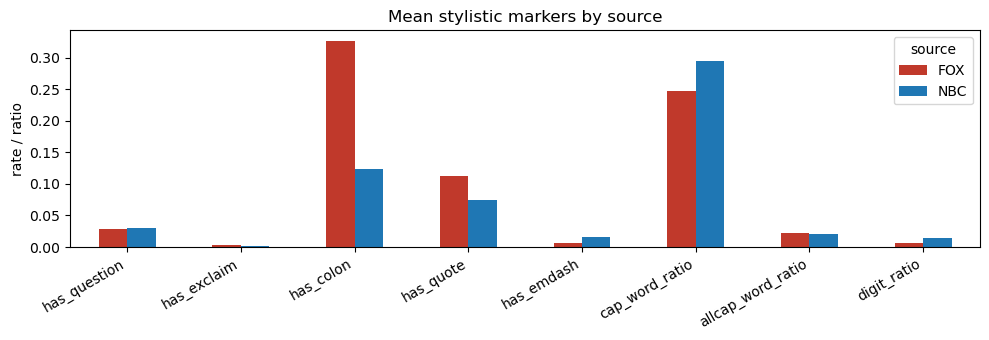

In [9]:
ax = style_means.T.plot(kind='bar', figsize=(10, 3.5), color=['#c0392b', '#1f77b4'])
ax.set_title('Mean stylistic markers by source')
ax.set_ylabel('rate / ratio')
ax.legend(title='source')
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()

## 6. Most distinctive words per source

TF-IDF is fit on cleaned, lowercased headlines and then we use
*log-odds with smoothing* to find words that lift one source over the other.

In [10]:
def clean_strict(x):
    s = unicodedata.normalize('NFKC', html.unescape(str(x))).lower()
    s = re.sub(r'https?://\S+|www\.\S+', ' ', s)
    s = re.sub(r'[^a-z0-9\s]', ' ', s)
    return re.sub(r'\s+', ' ', s).strip()

df['title_clean'] = df['title'].map(clean_strict)
vec = TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.95, sublinear_tf=True)
M = vec.fit_transform(df['title_clean'])
vocab = np.array(vec.get_feature_names_out())

fox_mass = np.asarray(M[df['source'].values == 'FOX'].sum(axis=0)).ravel()
nbc_mass = np.asarray(M[df['source'].values == 'NBC'].sum(axis=0)).ravel()
alpha = 0.5
fox_p = (fox_mass + alpha) / (fox_mass.sum() + alpha * len(vocab))
nbc_p = (nbc_mass + alpha) / (nbc_mass.sum() + alpha * len(vocab))
log_odds = np.log(fox_p / nbc_p)

k = 20
fox_top = pd.DataFrame({'token': vocab, 'fox_log_odds': log_odds, 'fox_count': fox_mass}).nlargest(k, 'fox_log_odds').reset_index(drop=True)
nbc_top = pd.DataFrame({'token': vocab, 'nbc_log_odds': -log_odds, 'nbc_count': nbc_mass}).nlargest(k, 'nbc_log_odds').reset_index(drop=True)
pd.concat([fox_top.add_prefix('fox_').rename(columns={'fox_token': 'fox_token'}), nbc_top.add_prefix('nbc_').rename(columns={'nbc_token': 'nbc_token'})], axis=1)

,fox_token,fox_fox_log_odds,fox_fox_count,nbc_token,nbc_nbc_log_odds,nbc_nbc_count
0,cnn,3.224514,13.853417,2026,3.819882,19.467664
1,in history,2.904466,9.922220,select,3.784993,18.783020
2,day in,2.862554,9.494428,nbc select,3.669868,16.686082
3,this day,2.862554,9.494428,jan,3.480267,25.502374
4,on this,2.829751,9.171902,of 2026,3.397653,12.590478
5,dem,2.725555,8.214853,products,3.157953,9.800424
6,american who,2.552527,6.830181,gifts,2.981886,8.137537
7,dems,2.498646,6.445682,in 2026,2.842062,7.010436
8,daughter,2.471804,6.261724,rioter,2.788925,6.621773
9,bruce,2.432831,6.003264,2026 according,2.728691,6.205464


## 7. Topic distribution

How does each source's `topic` column distribute? Useful for spotting
topic-driven shortcuts the model could exploit (or where domain shift could hurt).

In [11]:
if 'topic' in df.columns:
    top_topics = (df.groupby(['source', 'topic']).size().rename('n')
                  .reset_index().sort_values(['source', 'n'], ascending=[True, False])
                  .groupby('source').head(8))
    display(top_topics.reset_index(drop=True))
else:
    print('no topic column')

,source,topic,n
0,FOX,Media,231
1,FOX,POLITICS,196
2,FOX,LIFESTYLE,148
3,FOX,Donald Trump,76
4,FOX,Israel,58
5,FOX,HEALTH,55
6,FOX,ENTERTAINMENT,53
7,FOX,Kamala Harris,53
8,NBC,politics,679
9,NBC,news,623


## Findings

1. **Class balance** is mild (~52 / 48). Plain accuracy is a fine metric.
2. **Time coverage** is uneven across sources, so a *time-stratified* holdout
   (per-source most-recent X% as test) is more honest than a random split.
3. **Headline length differs**: NBC headlines are longer on average. Length is
   a real classification signal independent of word identity.
4. **Punctuation differs**: FOX uses scare quotes / colons / exclamations more
   often. Hand-crafted style features add signal on top of TF-IDF.
5. **Distinctive vocabulary**: each source has stable signature tokens —
   evidence that word and char n-gram TF-IDF should do most of the work.

These observations directly inform the modeling choices in `03_modeling.ipynb`.